In [58]:
import time
import numpy as np
from numba import cuda
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

In [59]:
def preprocess_patterns(N):
    # Предварительная обработка: для каждого символа создаём набор пар (n_idx, k)
    char_map = defaultdict(list)
    for idx, pattern in enumerate(N):
        for k, char in enumerate(pattern):
            char_map[char].append((idx, k))
    return char_map

def mass_search_CPU(H, N, char_map):
    h_len = len(H)
    n_count = len(N)

    R = np.zeros((n_count, h_len), dtype=np.int32)
    for i, pattern in enumerate(N):
        R[i, :] = len(pattern)

    for j, char in enumerate(H):
        if char in char_map:
            for n_idx, k in char_map[char]:
                pos = j - k
                if 0 <= pos < h_len:
                    R[n_idx, pos] -= 1

    # Интерпретация результатов - нулевые элементы соответствуют найденным подстрокам
    results = []
    for i, pattern in enumerate(N):
        positions = np.where(R[i, :] == 0)[0]
        if len(positions) > 0:
            results.append((i, positions.tolist()))

    return results, R

@cuda.jit
def mass_search_gpu_optimized(R, H, char_entries, char_offsets, char_keys):
   # GPU версия массового поиска с атомарными операциями
    j = cuda.grid(1)
    if j >= H.shape[0]:
        return

    char = H[j]

    key_idx = -1
    for i in range(char_keys.shape[0]):
        if char_keys[i] == char:
            key_idx = i
            break

    if key_idx >= 0:
        start = char_offsets[key_idx]
        end = char_offsets[key_idx + 1]
        for idx in range(start, end):
            n_idx = char_entries[idx, 0]
            k = char_entries[idx, 1]
            pos = j - k
            if 0 <= pos < R.shape[1]:
                cuda.atomic.sub(R, (n_idx, pos), 1)

def prepare_gpu_data(char_map, h_len, n_count, pattern_lengths):
    # Подготовка данных для GPU
    char_keys = np.array(sorted(char_map.keys()), dtype=np.uint8)

    char_entries_list = []
    char_offsets_list = [0]

    for key in char_keys:
        pairs = char_map[key]
        for pair in pairs:
            char_entries_list.append(pair)
        char_offsets_list.append(char_offsets_list[-1] + len(pairs))

    char_entries = np.array(char_entries_list, dtype=np.int32)
    char_offsets = np.array(char_offsets_list, dtype=np.int32)

    R_init = np.zeros((n_count, h_len), dtype=np.int32)
    for i, plen in enumerate(pattern_lengths):
        R_init[i, :] = plen

    return char_keys, char_entries, char_offsets, R_init

In [60]:
def run_single_experiment(h_size, n_patterns, min_len, max_len):
    # Запуск одного эксперимента, генерация буфера поиска H
    H = np.random.randint(0, 256, size=h_size, dtype=np.uint8)

    # Генерация подстрок N разной длины
    N = []
    for _ in range(n_patterns):
        length = np.random.randint(min_len, max_len + 1)
        pattern = np.random.randint(0, 256, size=length, dtype=np.uint8)
        N.append(pattern)

    # Предварительная обработка
    char_map = preprocess_patterns(N)
    pattern_lengths = np.array([len(p) for p in N], dtype=np.int32)

    # CPU
    start_cpu = time.time()
    cpu_results, R_cpu = mass_search_CPU(H, N, char_map)
    cpu_time = time.time() - start_cpu

    # GPU
    h_len = len(H)
    n_count = len(N)

    char_keys, char_entries, char_offsets, R_init = prepare_gpu_data(
        char_map, h_len, n_count, pattern_lengths
    )

    R_gpu = cuda.to_device(R_init)
    H_gpu = cuda.to_device(H)
    char_keys_gpu = cuda.to_device(char_keys)
    char_entries_gpu = cuda.to_device(char_entries)
    char_offsets_gpu = cuda.to_device(char_offsets)

    threads_per_block = 256
    blocks_per_grid = (h_size + threads_per_block - 1) // threads_per_block

    start_gpu = time.time()
    mass_search_gpu_optimized[blocks_per_grid, threads_per_block](
        R_gpu, H_gpu, char_entries_gpu, char_offsets_gpu, char_keys_gpu
    )
    cuda.synchronize()
    gpu_time = time.time() - start_gpu

    R_gpu_result = R_gpu.copy_to_host()
    match = np.array_equal(R_cpu, R_gpu_result)

    return cpu_time, gpu_time, match

In [61]:
def start_calculation(sizes, n_patterns, min_len, max_len):
    table_values_CPU = []
    table_values_GPU = []
    results_match = []

    for size in sizes:
        CPU_times = []
        GPU_times = []
        match = True

        for _ in range(10):
            cpu_t, gpu_t, m = run_single_experiment(size, n_patterns, min_len, max_len)
            CPU_times.append(cpu_t)
            GPU_times.append(gpu_t)
            if not m:
                match = False
                break

        table_values_CPU.append(np.mean(CPU_times))
        table_values_GPU.append(np.mean(GPU_times))
        results_match.append(match)
        print(f"Размер {size}: CPU={np.mean(CPU_times):.6f}, GPU={np.mean(GPU_times):.6f}, совпадение={match}")

    return np.array(table_values_CPU), np.array(table_values_GPU), results_match

In [63]:
# Параметры эксперимента
sizes = np.linspace(160, 1600, 10, dtype=int)  # размеры буфера
n_patterns = 50  # количество подстрок
min_len = 2      # минимальная длина подстроки
max_len = 10     # максимальная длина подстроки

print(f"Размеры буфера H: {sizes}")
print(f"Количество подстрок |N|: {n_patterns}")
print(f"Длина подстрок: от {min_len} до {max_len}")
print()

mas_CPU_time, mas_GPU_time, results_match = start_calculation(sizes, n_patterns, min_len, max_len)

speedup = mas_CPU_time / mas_GPU_time

Размеры буфера H: [ 160  320  480  640  800  960 1120 1280 1440 1600]
Количество подстрок |N|: 50
Длина подстрок: от 2 до 10

Размер 160: CPU=0.000263, GPU=0.000143, совпадение=True
Размер 320: CPU=0.000372, GPU=0.000144, совпадение=True
Размер 480: CPU=0.000489, GPU=0.000141, совпадение=True
Размер 640: CPU=0.000594, GPU=0.000175, совпадение=True
Размер 800: CPU=0.000725, GPU=0.000140, совпадение=True
Размер 960: CPU=0.000823, GPU=0.000134, совпадение=True
Размер 1120: CPU=0.000939, GPU=0.000166, совпадение=True
Размер 1280: CPU=0.001164, GPU=0.000138, совпадение=True
Размер 1440: CPU=0.001191, GPU=0.000133, совпадение=True
Размер 1600: CPU=0.001284, GPU=0.000139, совпадение=True


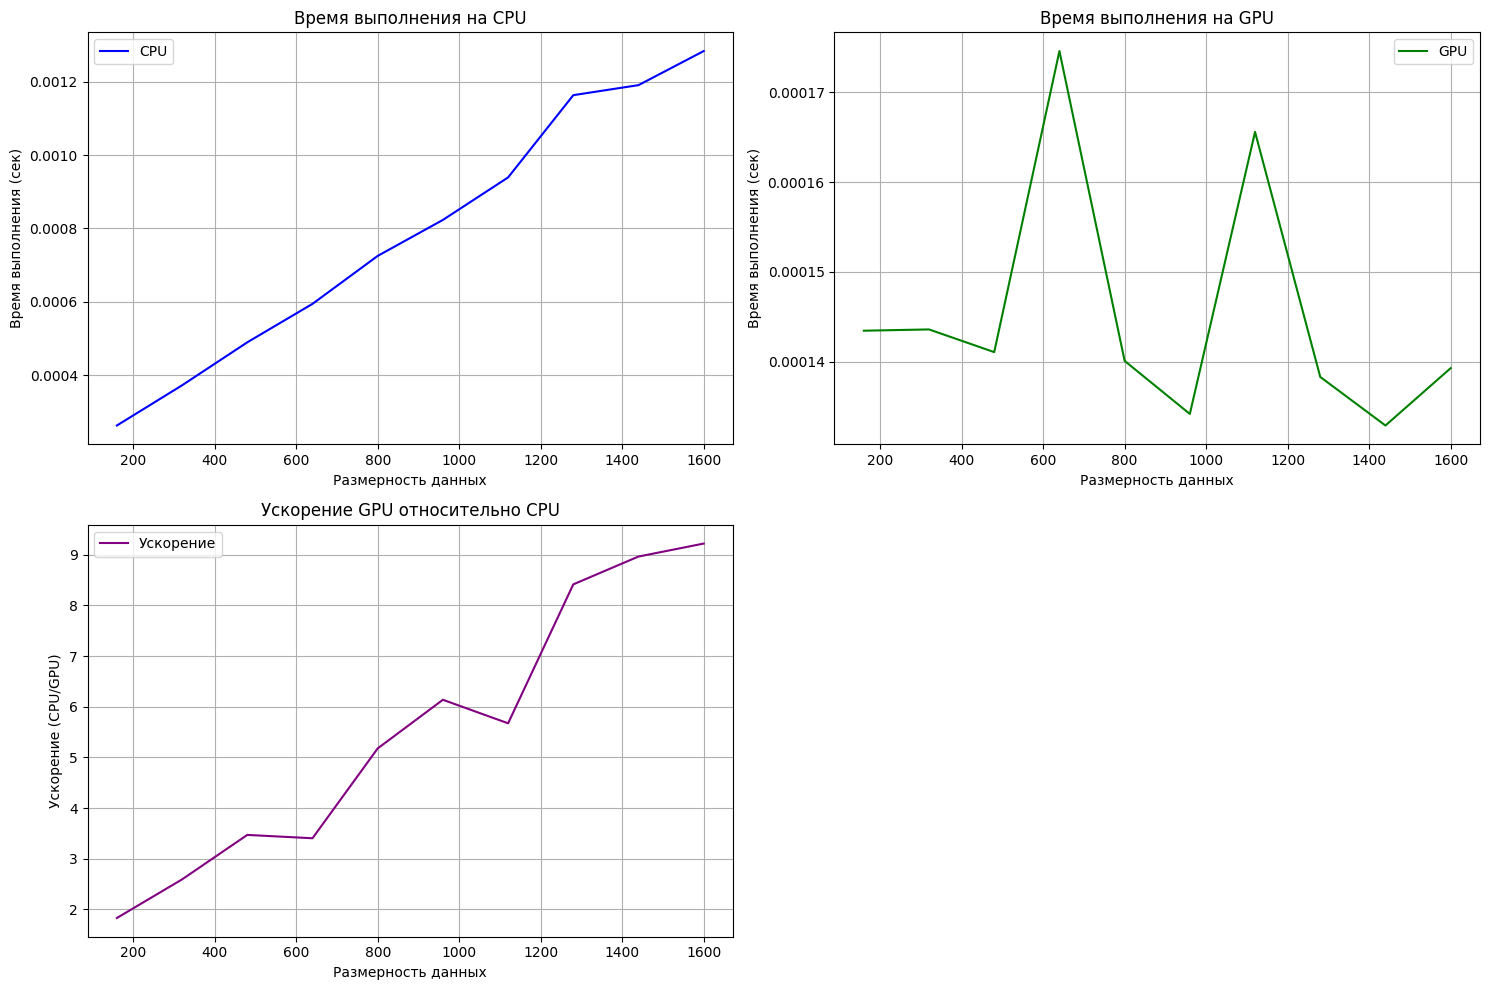

In [64]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(sizes, mas_CPU_time, label="CPU", color="blue")
plt.xlabel("Размерность данных")
plt.ylabel("Время выполнения (сек)")
plt.title("Время выполнения на CPU")
plt.grid()
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(sizes, mas_GPU_time, label="GPU", color="green")
plt.xlabel("Размерность данных")
plt.ylabel("Время выполнения (сек)")
plt.title("Время выполнения на GPU")
plt.grid()
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(sizes, speedup, label="Ускорение", color="purple")
plt.xlabel("Размерность данных")
plt.ylabel("Ускорение (CPU/GPU)")
plt.title("Ускорение GPU относительно CPU")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [65]:
results_df = pd.DataFrame({
    "Размер данных": sizes,
    "Время на CPU (среднее)": mas_CPU_time,
    "Время на GPU (среднее)": mas_GPU_time,
    "Ускорение (CPU/GPU)": speedup,
    "Результаты совпадают": results_match
})

print("\nРезультаты выполнения:\n")
print(results_df.to_string(index=False))


Результаты выполнения:

 Размер данных  Время на CPU (среднее)  Время на GPU (среднее)  Ускорение (CPU/GPU)  Результаты совпадают
           160                0.000263                0.000143             1.830286                  True
           320                0.000372                0.000144             2.592328                  True
           480                0.000489                0.000141             3.470081                  True
           640                0.000594                0.000175             3.404342                  True
           800                0.000725                0.000140             5.177191                  True
           960                0.000823                0.000134             6.137551                  True
          1120                0.000939                0.000166             5.673002                  True
          1280                0.001164                0.000138             8.415862                  True
          1440       